<a href="https://colab.research.google.com/github/ramalias/crop-monitoring-research/blob/main/01_%ED%8A%B9%EC%A7%95_%EB%B6%84%EC%84%9D_%EC%96%91%ED%8C%8C_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [91]:
import rasterio
from rasterio.mask import geometry_mask # for masking with vector geometries
import numpy as np    # math/array operations
import pandas as pd   # tables/time series handling
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline, UnivariateSpline
import geopandas as gpd
import os
import matplotlib.dates as mdates
from rasterstats import zonal_stats
import matplotlib.font_manager as fm

!apt-get install -y fonts-nanum -qq
!pip install contextily

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # avoids minus-sign glyph issues with Korean fonts

import contextily as ctx

In [92]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [213]:
RASTER_PATH = '/content/drive/MyDrive/00_shortcut/06_ARS/02_preprocess/Sentinel2/02_양파_연구/01_양파/06_final_preprocessing/2차/04_합천군/max_ndvi/S2_2024_2025_cheongdeokmyeon_merged_new_biweekly_maxndvi_final.tif'
PARCEL_PATH = '/content/drive/MyDrive/00_shortcut/06_ARS/04_월별진행사항/02_26년8월/label/2025/Hapcheon/onion_Hapcheon_2025.gpkg'

TARGET_EUPMYEON = "합천군 청덕면" #초계면, 청덕면
ADDR_COL = "STDG_ADDR"
LABEL_COL = "CROP_NM"
TARGET_LABEL = "양파"

NODATA_VALUE = -32768
SCALE_FACTOR = 1000
SEASON_START = "2024-10-01"
year = 2025
area = 'cheongdeok'

# All target vegetation indices (must match the band-name suffixes in your file)
# TARGET_INDICES = ["NDVI", "EVI", "EVI2", "NDRE", "GNDVI", "NDMI", "MSAVI2"]
TARGET_INDICES = ["NDVI", "EVI", "EVI2", "NDRE", "GNDVI", "NDMI", "MSAVI2"]

REGION_LABEL = TARGET_EUPMYEON
SEASON_LABEL = f"{year - 1}/{year}"

OUTPUT_DIR = "/content/drive/MyDrive/00_shortcut/01_양파/new_result"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Function

In [214]:
def load_filtered_onion_parcels(parcel_path, target_eupmyeon, addr_col, label_col, target_label):
    gdf_all = gpd.read_file(parcel_path)
    print(f"Loaded {len(gdf_all)} total parcels")
    print("Available columns:", gdf_all.columns.tolist())

    # --- filter by location ---
    if addr_col not in gdf_all.columns:
        print(f"WARNING: '{addr_col}' not found, skipping location filter")
        gdf_loc = gdf_all
    else:
        # Dynamically insert the target_eupmyeon variable into the regex
        matches = gdf_all[addr_col].str.extract(fr'{target_eupmyeon}\s+(\S+)')[0].unique()
        print(f"{target_eupmyeon} sub-areas found:", matches)

        gdf_loc = gdf_all[gdf_all[addr_col].str.contains(target_eupmyeon, na=False)].copy()
        print(f"{len(gdf_loc)} / {len(gdf_all)} features kept for {target_eupmyeon}")

    # --- filter by crop label (Onion) ---
    if label_col not in gdf_loc.columns:
        raise ValueError(f"'{label_col}' not found in columns: {gdf_loc.columns.tolist()}")

    print("Available labels in this area:", gdf_loc[label_col].unique())

    onion_parcels = gdf_loc[gdf_loc[label_col] == target_label].copy()

    if 'MIX_CRP' in onion_parcels.columns:
        onion_parcels = onion_parcels[
            onion_parcels['MIX_CRP'].isna() |
            (onion_parcels['MIX_CRP'].astype(str).str.strip() == '') |
            (onion_parcels['MIX_CRP'].astype(str).str.strip() == 'None')
        ]

    print(f"Pure onion parcels kept: {len(onion_parcels)} / {len(gdf_loc)}")

    if len(onion_parcels) == 0:
        raise ValueError(
            f"No pure parcels found with {label_col} == '{target_label}' in {target_eupmyeon}. "
            f"Check label spelling/values above."
        )

    return onion_parcels

def build_onion_mask(raster_path, onion_parcels):
    with rasterio.open(raster_path) as src:
        raster_crs = src.crs
        transform = src.transform
        out_shape = (src.height, src.width)

    if onion_parcels.crs != raster_crs:
        raise ValueError(
            f"CRS mismatch: parcels are {onion_parcels.crs}, raster is {raster_crs}. "
            f"Reproject onion_parcels with .to_crs(raster_crs) before calling this."
        )

    mask = geometry_mask(
        onion_parcels.geometry,
        out_shape=out_shape,
        transform=transform,
        invert=True
    )
    print(f"Onion pixel count: {mask.sum()} out of {mask.size} total pixels "
          f"({100 * mask.sum() / mask.size:.2f}%)")

    if mask.sum() == 0:
        raise ValueError(
            "Mask has 0 onion pixels. Likely CRS mismatch or parcels outside "
            "raster extent -- check gdf.total_bounds vs raster bounds."
        )
    return mask

def find_bands_by_suffix(raster_path, suffix="_NDVI"):
    band_map = {}
    with rasterio.open(raster_path) as src:
        for i, desc in enumerate(src.descriptions, start=1):
            if desc is not None and desc.endswith(suffix):
                month_str = desc.replace(suffix, "")
                band_map[i] = month_str
    return band_map


def extract_ndvi_series(raster_path, band_map, mask,
                         scale_factor=SCALE_FACTOR, fill_value=NODATA_VALUE):
    records = []
    with rasterio.open(raster_path) as src:
        for band_idx, month_str in band_map.items():
            arr = src.read(band_idx).astype("float32")
            arr = np.where(arr == fill_value, np.nan, arr)
            arr = np.where(mask, arr, np.nan)
            arr = arr / scale_factor
            records.append({"date": month_str, "ndvi": np.nanmean(arr)})

    df = pd.DataFrame(records)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df["day_num"] = (df["date"] - df["date"].min()).dt.days
    return df

def beck_function(t, base, vmax, m1, m2, n1, n2):
    rising = 1 / (1 + np.exp(-m1 * (t - m2)))
    falling = 1 / (1 + np.exp(-n1 * (t - n2)))
    return base + (vmax - base) * (rising + falling - 1)


def fit_beck(day_num, ndvi):
    if len(day_num) == 0 or len(ndvi) == 0:
        raise ValueError(
            "fit_beck received an empty array -- day_num/ndvi have 0 points. "
            "This usually means df_season ended up empty (e.g. all-NaN "
            "cloud-blocked composites for this myeon/index, or the cell "
            "was run out of order against stale variables). Re-run this "
            "cell from the top (Runtime > Restart and run all) and check "
            "the printed df_season for NaNs before this line."
        )
    if np.all(np.isnan(ndvi)):
        raise ValueError("fit_beck: ndvi is entirely NaN -- check cloud masking for this date range.")
    base0 = np.nanmin(ndvi)
    vmax0 = np.nanmax(ndvi)
    mid = (day_num.max() + day_num.min()) / 2
    p0 = [base0, vmax0, 0.05, mid - 20, 0.05, mid + 20]
    lower_bounds = [0, 0, 0.001, day_num.min(), 0.001, day_num.min()]
    upper_bounds = [1, 1, 1.0, day_num.max(), 1.0, day_num.max()]
    try:
        popt, _ = curve_fit(beck_function, day_num, ndvi, p0=p0,
                             bounds=(lower_bounds, upper_bounds), maxfev=20000)
    except RuntimeError as e:
        print(f"Beck fit failed: {e}")
        return None, None, None
    dense_days = np.linspace(day_num.min(), day_num.max(), 500)
    return popt, dense_days, beck_function(dense_days, *popt)

def _loocv_spline_smoothing(day_num, ndvi, n_candidates=40):
    var = np.var(ndvi)
    n = len(day_num)
    if var == 0 or n < 4:
        return max(var * n * 0.1, 1e-6)

    candidates = np.geomspace(var * n * 0.001, var * n * 2, n_candidates)
    best_s, best_err = candidates[0], np.inf
    for s in candidates:
        errs = []
        for i in range(n):
            x_train = np.delete(day_num, i)
            y_train = np.delete(ndvi, i)
            try:
                spl = UnivariateSpline(x_train, y_train, s=s)
                pred = spl(day_num[i])
                errs.append((pred - ndvi[i]) ** 2)
            except Exception:
                errs.append(np.inf)
        mse = np.mean(errs)
        if mse < best_err:
            best_err, best_s = mse, s
    return best_s


def fit_spline(day_num, ndvi, smoothing_factor=None):
    if smoothing_factor is None:
        smoothing_factor = _loocv_spline_smoothing(day_num, ndvi)
    spl = UnivariateSpline(day_num, ndvi, s=smoothing_factor)
    dense_days = np.linspace(day_num.min(), day_num.max(), 500)
    return spl, dense_days, spl(dense_days)

def extract_derivative_points(dense_days, fitted_curve, ignore_percent=0.1):
    dt = dense_days[1] - dense_days[0]
    derivative = np.gradient(fitted_curve, dt)

    num_points = len(dense_days)
    ignore_count = int(num_points * ignore_percent)

    search_start_idx = ignore_count
    search_end_idx = num_points - ignore_count

    if search_end_idx <= search_start_idx:
        search_start_idx = 0
        search_end_idx = num_points
        print(f"Warning: ignore_percent ({(ignore_percent*100):.0f}%) too high, using full range for derivative point search.")

    # --- Find the trough first: a pre-season plateau/artifact can sit
    # higher than the real peak (e.g. leftover-crop signal before onion
    # is even in the ground). Anchoring POS search to start AFTER the
    # trough guarantees that plateau can never be picked as POS. ---
    trough_idx_relative = np.argmin(fitted_curve[search_start_idx:search_end_idx])
    trough_idx = search_start_idx + trough_idx_relative

    # --- POS: highest fitted-curve value, searched ONLY after the trough ---
    pos_search_start = trough_idx
    pos_idx_relative = np.argmax(fitted_curve[pos_search_start:search_end_idx])
    pos_idx = pos_search_start + pos_idx_relative

    # --- SOS: steepest rise, searched only BEFORE the peak (unchanged) ---
    if pos_idx > search_start_idx:
        sos_idx = search_start_idx + np.argmax(derivative[search_start_idx:pos_idx])
    else:
        sos_idx = search_start_idx

    # --- EOS: steepest fall, searched only AFTER the peak (unchanged) ---
    if search_end_idx - 1 > pos_idx:
        eos_idx = (pos_idx + 1) + np.argmin(derivative[pos_idx + 1:search_end_idx])
    else:
        eos_idx = search_end_idx - 1

    return {
        "SOS_day": dense_days[sos_idx],
        "POS_day": dense_days[pos_idx],
        "EOS_day": dense_days[eos_idx],
    }

def extract_ndvi_series(raster_path, band_map, mask,
                         scale_factor=SCALE_FACTOR, fill_value=NODATA_VALUE):
    records = []
    with rasterio.open(raster_path) as src:
        for band_idx, month_str in band_map.items():
            arr = src.read(band_idx).astype("float32")
            arr = np.where(arr == fill_value, np.nan, arr)
            arr = np.where(mask, arr, np.nan)
            arr = arr / scale_factor
            #records.append({"date": month_str, "ndvi": np.nanmean(arr)})
            records.append({"date": month_str, "ndvi": np.nanmedian(arr)})

    df = pd.DataFrame(records)
    # Custom parsing for 'YYYY-MM-PX' format
    def parse_custom_date(date_str):
        parts = date_str.split('-')
        year = parts[0]
        month = parts[1]
        period = parts[2]
        if period == 'P1':
            day = '01'
        elif period == 'P2':
            day = '15' # Assuming P2 is mid-month for bi-weekly data
        else:
            raise ValueError(f"Unknown period format: {period}")
        return pd.to_datetime(f"{year}-{month}-{day}")

    df["date"] = df["date"].apply(parse_custom_date)
    df = df.sort_values("date").reset_index(drop=True)
    df["day_num"] = (df["date"] - df["date"].min()).dt.days
    return df

## Analysis

In [ ]:
# Get the raster CRS first
with rasterio.open(RASTER_PATH) as src:
    raster_crs = src.crs

onion_parcels = load_filtered_onion_parcels(PARCEL_PATH, TARGET_EUPMYEON, ADDR_COL, LABEL_COL, TARGET_LABEL)
# Reproject onion_parcels to match the raster CRS
onion_parcels = onion_parcels.to_crs(raster_crs)
onion_mask = build_onion_mask(RASTER_PATH, onion_parcels)

ndvi_band_map = find_bands_by_suffix(RASTER_PATH, suffix="_NDVI")
print("NDVI bands found:", ndvi_band_map)

df = extract_ndvi_series(RASTER_PATH, ndvi_band_map, onion_mask)
print(df)

df_season = df[df["date"] >= SEASON_START].copy()

n_nan_before = df_season["ndvi"].isna().sum()
if n_nan_before > 0:
    print(f"NOTE: Dropping {n_nan_before} missing NDVI values instead of interpolating.")
    df_season = df_season.dropna(subset=["ndvi"]).copy()

# Sort by date and calculate the day numbers for the remaining valid points
df_season = df_season.sort_values("date").reset_index(drop=True)
df_season["day_num"] = (df_season["date"] - df_season["date"].min()).dt.days

# --- Diagnostic print ---
print(f"\ndf_season after SEASON_START filter "
      f"{len(df_season)} rows")
print(df_season[["date", "ndvi", "day_num"]])

day_num = df_season["day_num"].values
ndvi = df_season["ndvi"].values

# Define the output path for the Excel file
excel_path = os.path.join(OUTPUT_DIR, f"ndvi_onion_{area}_{year}.xlsx")
# Export the DataFrame to Excel
df_season.to_excel(excel_path, index=False)

print(f"Data successfully exported to: {excel_path}")

Loaded 539 total parcels
Available columns: ['ID', 'UID', 'CLSF_NM', 'CLSF_CD', 'STDG_CD', 'STDG_ADDR', 'PNU', 'LDCG_CD', 'SB_PNU', 'SB_LDCG_CD', 'AREA', 'CAD_CON_RA', 'SOURCE_NM', 'SOURCE_CD', 'FLIGHT_YMD', 'UPDT_YMD', 'UPDT_TP_NM', 'UPDT_TP_CD', 'CHG_RSN_NM', 'CHG_RSN_CD', 'FL_ARMT_YN', 'O_UID', 'O_CLSF_NM', 'FMAP_ID', 'PARCEL_ID', 'LAND_TYP', 'SURV_AREA', 'CROP_NM', 'PLT_RATE', 'MIX_CRP', 'MIX_RT', 'geometry']
합천군 청덕면 sub-areas found: [nan '앙진리' '적포리' '두곡리' '초곡리' '가현리' '대부리' '운봉리' '소례리' '성태리' '모리' '삼학리'
 '미곡리']
270 / 539 features kept for 합천군 청덕면
Available labels in this area: ['양파']
Pure onion parcels kept: 270 / 270
Onion pixel count: 7000 out of 1064130 total pixels (0.66%)
NDVI bands found: {221: '2024-08-P1', 228: '2024-08-P2', 235: '2024-09-P1', 242: '2024-09-P2', 249: '2024-10-P1', 256: '2024-10-P2', 263: '2024-11-P1', 270: '2024-11-P2', 277: '2024-12-P1', 284: '2024-12-P2', 291: '2025-01-P1', 298: '2025-01-P2', 305: '2025-02-P1', 312: '2025-02-P2', 319: '2025-03-P1', 326: '2

In [ ]:
beck_params, beck_days, beck_curve = fit_beck(day_num, ndvi)
spline_obj, spline_days, spline_curve = fit_spline(day_num, ndvi)
points = extract_derivative_points(spline_days, spline_curve)

base_date = df_season["date"].min()
for key, val in points.items():
    actual_date = base_date + pd.Timedelta(days=val)
    print(f"{key}: day {val:.1f} -> {actual_date.date()}")

In [ ]:
# Plot
plt.figure(figsize=(9, 5))
plt.plot(day_num, ndvi, 'o', label="Observed NDVI", color="black")
if beck_curve is not None:
    plt.plot(beck_days, beck_curve, '-', label="Beck fit", color="tab:orange")
plt.plot(spline_days, spline_curve, '-', label="Smoothed spline fit", color="tab:blue")

for key, val in points.items():
    idx = np.argmin(np.abs(spline_days - val))
    plt.axvline(val, linestyle="--", alpha=0.5)
    plt.text(val, spline_curve[idx], key, rotation=90, va="bottom")

# Standardize the y-axis for cross-area comparison
plt.ylim(0.0, 0.9)

plt.xlabel("Days since first observation")
plt.ylabel("NDVI")
plt.title(f"Onion NDVI Time Series - {area}-myeon {year}")
plt.legend()
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, f"ndvi_onion_{area}_{year}.png")
plt.savefig(plot_path, dpi=150)
plt.show()

In [ ]:
# Convert day_num to real dates for the primary (bottom) axis
plot_dates = [df_season["date"].min() + pd.Timedelta(days=d) for d in day_num]
spline_plot_dates = [df_season["date"].min() + pd.Timedelta(days=d) for d in spline_days]
beck_plot_dates = [df_season["date"].min() + pd.Timedelta(days=d) for d in beck_days] if beck_curve is not None else None

fig, ax1 = plt.subplots(figsize=(9, 5))

# --- Bottom axis: dates ---
# Updated label to reflect the Median usage
ax1.plot(plot_dates, ndvi, 'o', label="Observed NDVI (Median)", color="black")
if beck_curve is not None:
    ax1.plot(beck_plot_dates, beck_curve, '-', label="Beck fit", color="tab:orange")
ax1.plot(spline_plot_dates, spline_curve, '-', label="Smoothed spline fit", color="tab:blue")

for key, val in points.items():
    actual_date = df_season["date"].min() + pd.Timedelta(days=val)
    idx = np.argmin(np.abs(spline_days - val))
    ax1.axvline(actual_date, linestyle="--", alpha=0.5)
    ax1.text(actual_date, spline_curve[idx], key, rotation=90, va="bottom")

ax1.set_xlabel("Month")
ax1.set_ylabel("NDVI")

# Standardize the y-axis for cross-area comparison and text headroom
ax1.set_ylim(0.0, 0.9)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# Fixed the visual offset of rotated labels
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# --- Top axis: day_num (shares the same y-axis, mirrors the same range) ---
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())  # match the same range as bottom axis

# Build day_num ticks aligned to the same date positions as bottom axis
date_ticks = ax1.get_xticks()
day_num_ticks = [(mdates.num2date(d).replace(tzinfo=None) - df_season["date"].min()).days for d in date_ticks]
ax2.set_xticks(date_ticks)
ax2.set_xticklabels(day_num_ticks)
ax2.set_xlabel("Days since first observation")

ax1.set_title(f"Onion NDVI Time Series - {area}-myeon {year} ")
ax1.legend()

plot_path = os.path.join(OUTPUT_DIR, f"ndvi_onion2_{area}_{year}.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight") # Added bbox_inches="tight" to prevent label cutoff
plt.show()

In [ ]:
# Convert day_num to real dates for the primary (bottom) axis
plot_dates = [base_date + pd.Timedelta(days=d) for d in day_num]
spline_plot_dates = [base_date + pd.Timedelta(days=d) for d in spline_days]
beck_plot_dates = [base_date + pd.Timedelta(days=d) for d in beck_days] if beck_curve is not None else None

fig, ax1 = plt.subplots(figsize=(9, 6))

# --- Bottom axis: dates ---
# Updated label to reflect Median usage
ax1.plot(plot_dates, ndvi, 'o', label="Observed NDVI", color="black")
if beck_curve is not None:
    ax1.plot(beck_plot_dates, beck_curve, '-', label="Beck fit", color="tab:orange")
ax1.plot(spline_plot_dates, spline_curve, '-', label="Smoothed spline fit", color="tab:blue")

for key, val in points.items():
    actual_date = base_date + pd.Timedelta(days=val)
    idx = np.argmin(np.abs(spline_days - val))
    ax1.axvline(actual_date, linestyle="--", alpha=0.5)
    ax1.text(actual_date, spline_curve[idx], key, rotation=90, va="bottom")

ax1.set_xlabel("Date")
ax1.set_ylabel("NDVI")

# Standardize the y-axis for cross-area comparison
# (This replaces the need for the y_max + 0.05 headroom calculation)
ax1.set_ylim(0.0, 0.9)

# Date formatting (Biweekly, anchored right)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
ax1.xaxis.set_major_locator(mdates.DayLocator(bymonthday=(1, 15)))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# --- Top axis: day_num ---
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())  # match the same range as bottom axis

# Build day_num ticks aligned to the same date positions as bottom axis
date_ticks = ax1.get_xticks()
day_num_ticks = [(mdates.num2date(d).replace(tzinfo=None) - base_date).days for d in date_ticks]
ax2.set_xticks(date_ticks)
ax2.set_xticklabels(day_num_ticks)
ax2.set_xlabel("Days since first observation")

ax1.set_title(f"Onion NDVI Time Series - {area}-myeon {year} ")
ax1.legend()
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, f"ndvi_onion_{area}_{year}.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
onion_parcels.to_crs(epsg=3857).plot(ax=ax, facecolor="lightgreen", edgecolor="black", linewidth=0.5, alpha=0.6)
ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
ax.set_title(f"Onion Parcels — {TARGET_EUPMYEON}")
ax.set_axis_off()
plt.show()

In [ ]:
def find_bands_by_suffix_all(raster_path, suffix):
    band_map = {}
    with rasterio.open(raster_path) as src:
        for i, desc in enumerate(src.descriptions, start=1):
            if desc is not None and desc.endswith(f"_{suffix}"):
                band_map[i] = desc.replace(f"_{suffix}", "")
    return band_map


def extract_index_series_all(raster_path, band_map, mask,
                          scale_factor=SCALE_FACTOR, fill_value=NODATA_VALUE):
    records = []
    with rasterio.open(raster_path) as src:
        for band_idx, month_str in band_map.items():
            arr = src.read(band_idx).astype("float32")
            arr = np.where(arr == fill_value, np.nan, arr)
            arr = np.where(mask, arr, np.nan)
            arr = arr / scale_factor
            records.append({"date": month_str, "value": np.nanmean(arr)})

    df = pd.DataFrame(records)
    # Custom parsing for 'YYYY-MM-PX' format
    def parse_custom_date(date_str):
        parts = date_str.split('-')
        year = parts[0]
        month = parts[1]
        period = parts[2]
        if period == 'P1':
            day = '01'
        elif period == 'P2':
            day = '15' # Assuming P2 is mid-month for bi-weekly data
        else:
            raise ValueError(f"Unknown period format: {period}")
        return pd.to_datetime(f"{year}-{month}-{day}")

    df["date"] = df["date"].apply(parse_custom_date)
    df = df.sort_values("date").reset_index(drop=True)
    df["day_num"] = (df["date"] - df["date"].min()).dt.days
    return df

def extract_derivative_points_all(dense_days, fitted_curve, ignore_percent=0.1):
    dt = dense_days[1] - dense_days[0]
    derivative = np.gradient(fitted_curve, dt)

    num_points = len(dense_days)
    ignore_count = int(num_points * ignore_percent)

    search_start_idx = ignore_count
    search_end_idx = num_points - ignore_count

    if search_end_idx <= search_start_idx:
        search_start_idx = 0
        search_end_idx = num_points
        print(f"Warning: ignore_percent ({(ignore_percent*100):.0f}%) too high, using full range for derivative point search.")

    trough_idx_relative = np.argmin(fitted_curve[search_start_idx:search_end_idx])
    trough_idx = search_start_idx + trough_idx_relative

    pos_search_start = trough_idx
    pos_idx_relative = np.argmax(fitted_curve[pos_search_start:search_end_idx])
    pos_idx = pos_search_start + pos_idx_relative

    if pos_idx > search_start_idx:
        sos_idx = search_start_idx + np.argmax(derivative[search_start_idx:pos_idx])
    else:
        sos_idx = search_start_idx

    if search_end_idx - 1 > pos_idx:
        eos_idx = (pos_idx + 1) + np.argmin(derivative[pos_idx + 1:search_end_idx])
    else:
        eos_idx = search_end_idx - 1

    return {
        "SOS_idx": sos_idx, "POS_idx": pos_idx, "EOS_idx": eos_idx,
        "SOS_day": dense_days[sos_idx], "POS_day": dense_days[pos_idx], "EOS_day": dense_days[eos_idx],
    }, derivative

In [ ]:
def extract_curve_shape_features(dense_days, fitted_curve, derivative, points):
    """
    Growth Rate            : avg rate of increase from SOS to POS (peak)
    Max Growth Rate         : steepest instantaneous rise (derivative at SOS)
    Peak Timing              : day of peak value (= POS_day)
    Max Decline Rate         : steepest instantaneous fall (derivative at EOS)
    Post Peak Decline Rate  : avg rate of decrease from POS (peak) to end of series
    AUC                      : area under the fitted curve (trapezoidal integration)
    """
    sos_idx, pos_idx, eos_idx = points["SOS_idx"], points["POS_idx"], points["EOS_idx"]

    # Growth Rate: average slope from SOS to POS
    if pos_idx > sos_idx:
        growth_rate = (fitted_curve[pos_idx] - fitted_curve[sos_idx]) / \
                      (dense_days[pos_idx] - dense_days[sos_idx])
    else:
        growth_rate = np.nan

    # Post Peak Decline Rate: average slope from POS to the end of the series
    if len(dense_days) - 1 > pos_idx:
        post_peak_decline_rate = (fitted_curve[-1] - fitted_curve[pos_idx]) / \
                                  (dense_days[-1] - dense_days[pos_idx])
    else:
        post_peak_decline_rate = np.nan

    max_growth_rate = derivative[sos_idx]     # steepest rise
    max_decline_rate = derivative[eos_idx]    # steepest fall (negative)
    peak_timing = dense_days[pos_idx]
    auc = np.trapezoid(fitted_curve, dense_days)  # area under curve

    return {
        "Growth_Rate": growth_rate,
        "Max_Growth_Rate": max_growth_rate,
        "Peak_Timing_day": peak_timing,
        "Max_Decline_Rate": max_decline_rate,
        "Post_Peak_Decline_Rate": post_peak_decline_rate,
        "AUC": auc,
    }

In [ ]:
all_results = []
all_series = {}
all_curves = {}

for index_name in TARGET_INDICES:
    print(f"\n{'='*70}\nProcessing: {index_name}\n{'='*70}")

    band_map = find_bands_by_suffix_all(RASTER_PATH, suffix=index_name)
    if len(band_map) == 0:
        print(f"WARNING: no bands found for suffix '_{index_name}', skipping.")
        continue

    df = extract_index_series_all(RASTER_PATH, band_map, onion_mask)
    df_season = df[df["date"] >= SEASON_START].copy()


    full_dates = pd.date_range(
        start=df_season["date"].min(), end=df_season["date"].max(), freq="SMS"
    )  # semi-month-start: approximates the P1/P2 biweekly grid

    full_dates = []
    d = df_season["date"].min()
    end = df_season["date"].max()
    cur = pd.Timestamp(year=d.year, month=d.month, day=1)
    while cur <= end:
        full_dates.append(cur)
        full_dates.append(cur + pd.Timedelta(days=14))
        cur = (cur + pd.Timedelta(days=32)).replace(day=1)
    full_dates = pd.DatetimeIndex(sorted(set(full_dates)))
    full_dates = full_dates[(full_dates >= d) & (full_dates <= end)]

    df_season = (
        df_season.set_index("date")
        .reindex(full_dates)
        .rename_axis("date")
        .reset_index()
    )
    n_missing_rows = df_season["value"].isna().sum() - df["value"].isna().sum() \
        if "value" in df.columns else df_season["value"].isna().sum()
    if len(full_dates) > len(df[df["date"] >= SEASON_START]):
        print(f"NOTE: reindexed to {len(full_dates)} expected biweekly dates "
              f"(raster only had {len(df[df['date'] >= SEASON_START])} bands "
              f"in season for {index_name} -- some composites were fully "
              f"missing from the raster, not just cloud-blocked within the mask).")

    df_season["day_num"] = (df_season["date"] - df_season["date"].min()).dt.days

    n_nan = df_season["value"].isna().sum()
    if n_nan > 0:
        print(f"NOTE: {n_nan} NaN value(s) in {index_name} series "
              f"(likely cloud-blocked composite) -- interpolating.")
        df_season["value"] = df_season["value"].interpolate(
            method="linear", limit_direction="both"
        )
    # if interpolation still leaves NaN at the very edges (e.g. first/last
    # point is missing with nothing on that side to interpolate from),
    # fall back to dropping just those rows
    remaining_nan = df_season["value"].isna().sum()
    if remaining_nan > 0:
        print(f"WARNING: {remaining_nan} NaN(s) remain after interpolation "
              f"for {index_name} (edge gaps) -- dropping those rows.")
        df_season = df_season.dropna(subset=["value"]).copy()
        df_season["day_num"] = (df_season["date"] - df_season["date"].min()).dt.days

    if len(df_season) < 4:
        print(f"WARNING: only {len(df_season)} points in season window for {index_name}, "
              f"fitting may be unreliable.")
        if len(df_season) == 0:
            print(f"SKIPPING {index_name}: no valid data points after cleaning.")
            continue

    day_num = df_season["day_num"].values
    values = df_season["value"].values
    base_date = df_season["date"].min()

    spline_obj, dense_days, fitted_curve = fit_spline(day_num, values)
    points, derivative = extract_derivative_points_all(dense_days, fitted_curve)
    features = extract_curve_shape_features(dense_days, fitted_curve, derivative, points)

    sos_date = base_date + pd.Timedelta(days=points["SOS_day"])
    pos_date = base_date + pd.Timedelta(days=points["POS_day"])
    eos_date = base_date + pd.Timedelta(days=points["EOS_day"])

    result_row = {
        "Index": index_name,
        "SOS_date": sos_date,
        "POS_date": pos_date,
        "EOS_date": eos_date,
        "SOS_month": sos_date.strftime("%Y-%m"),
        "POS_month": pos_date.strftime("%Y-%m"),
        "EOS_month": eos_date.strftime("%Y-%m"),
        **features,
    }
    all_results.append(result_row)
    all_series[index_name] = df_season
    all_curves[index_name] = (dense_days, fitted_curve, points, base_date)

    print(f"SOS: {sos_date.strftime('%b %Y')} | POS: {pos_date.strftime('%b %Y')} | "
          f"EOS: {eos_date.strftime('%b %Y')}")
    print(f"Growth Rate: {features['Growth_Rate']:.5f}/day | "
          f"Max Growth Rate: {features['Max_Growth_Rate']:.5f}/day")
    print(f"Post-Peak Decline Rate: {features['Post_Peak_Decline_Rate']:.5f}/day | "
          f"Max Decline Rate: {features['Max_Decline_Rate']:.5f}/day")
    print(f"AUC: {features['AUC']:.2f}")

# --- Summary table (OUTSIDE the loop, so 0-indent / top-level) ---
summary_df = pd.DataFrame(all_results)
summary_df.insert(0, "region", REGION_LABEL)
summary_df.insert(1, "season", SEASON_LABEL)
print("\n" + "=" * 70)
print("SUMMARY: Temporal & Spectral Characteristics Across All Indices")
print("=" * 70)
print(summary_df.to_string(index=False))

summary_path = os.path.join(
    OUTPUT_DIR, f"onion_multi_index_summary_{area}_{year}.csv"
)  # FIXED: filename now includes area/year -- previously this was
   # a fixed name and got overwritten every time you ran a new myeon
summary_df.to_csv(summary_path, index=False)
print(f"\nSaved summary table to: {summary_path}")

# --- Plot (also OUTSIDE the loop) ---
plt.figure(figsize=(10, 6))
for index_name, (dense_days, fitted_curve, points, base_date) in all_curves.items():
    norm_curve = (fitted_curve - np.nanmin(fitted_curve)) / \
                 (np.nanmax(fitted_curve) - np.nanmin(fitted_curve))
    plot_dates = [base_date + pd.Timedelta(days=d) for d in dense_days]
    plt.plot(plot_dates, norm_curve, label=index_name)

plt.xlabel("Month")
plt.ylabel("Normalized Index Value (0-1)")
plt.title(f"Onion Multi-Index Temporal Profiles ({area}-myeon {year} )")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plot_path = os.path.join(
    OUTPUT_DIR, f"onion_multi_index_profiles_{area}_{year}.png"
)
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved plot to: {plot_path}")

# per parcel (필지)

In [215]:
onion_parcels = onion_parcels.reset_index(drop=True)
onion_parcels["parcel_id"] = onion_parcels.index.astype(str)

In [216]:
from rasterstats import zonal_stats

def extract_index_series_per_parcel(raster_path, band_map, parcels_gdf,
                                     id_col="parcel_id",
                                     scale_factor=SCALE_FACTOR,
                                     fill_value=NODATA_VALUE):
    records = []
    with rasterio.open(raster_path) as src:
        affine = src.transform
        for band_idx, date_str in band_map.items():
            arr = src.read(band_idx).astype("float32")
            arr = np.where(arr == fill_value, np.nan, arr)

            stats = zonal_stats(
                parcels_gdf, arr, affine=affine,
                stats=["mean", "count"],
                nodata=np.nan,
                all_touched=True
            )
            for pid, s in zip(parcels_gdf[id_col], stats):
                mean_val = s["mean"] / scale_factor if s["mean"] is not None else np.nan
                records.append({
                    "parcel_id": pid, "date": date_str,
                    "value": mean_val, "pixel_count": s["count"]
                })

    df = pd.DataFrame(records)
    df["date"] = df["date"].apply(parse_custom_date)
    return df

In [217]:
def parse_custom_date(date_str):
    parts = date_str.split('-')
    year, month, period = parts[0], parts[1], parts[2]
    if period == 'P1':
        day = '01'
    elif period == 'P2':
        day = '15'
    else:
        raise ValueError(f"Unknown period format: {period}")
    return pd.to_datetime(f"{year}-{month}-{day}")

In [218]:
MIN_PIXELS = 4

df_parcel = extract_index_series_per_parcel(RASTER_PATH, ndvi_band_map, onion_parcels)
print(df_parcel.columns.tolist())
print(df_parcel.head())


pixel_counts = df_parcel.groupby("parcel_id")["pixel_count"].max()
valid_parcels = pixel_counts[pixel_counts >= MIN_PIXELS].index

['parcel_id', 'date', 'value', 'pixel_count']
  parcel_id       date     value  pixel_count
0         0 2023-08-01  0.818727           11
1         1 2023-08-01  0.845053           19
2         2 2023-08-01  0.418186           43
3         3 2023-08-01  0.836530           83
4         4 2023-08-01  0.393588           17


In [219]:
BASE_DATE = pd.Timestamp(SEASON_START)
df["day_num"] = (df["date"] - BASE_DATE).dt.days

In [220]:
all_results = []
all_curves_by_parcel = {}
failed_parcels = []

for pid in valid_parcels:
    sub = df_parcel[df_parcel["parcel_id"] == pid].dropna(subset=["value"]).sort_values("date")
    if len(sub) < 4:
        failed_parcels.append((pid, "too few valid points"))
        continue
    try:
        day_num = sub["day_num"].values
        values = sub["value"].values
        base_date = BASE_DATE  # since day_num is now anchored to the shared BASE_DATE

        spline_obj, dense_days, fitted_curve = fit_spline(day_num, values)
        points, derivative = extract_derivative_points_all(dense_days, fitted_curve)
        features = extract_curve_shape_features(dense_days, fitted_curve, derivative, points)
        features["parcel_id"] = pid
        features["n_pixels_max"] = pixel_counts[pid]
        all_results.append(features)

        all_curves_by_parcel[pid] = (dense_days, fitted_curve, points, base_date)  # <-- add this
    except Exception as e:
        failed_parcels.append((pid, str(e)))

print(f"Fitted {len(all_results)} / {len(valid_parcels)} parcels; {len(failed_parcels)} failed.")

Fitted 0 / 300 parcels; 300 failed.


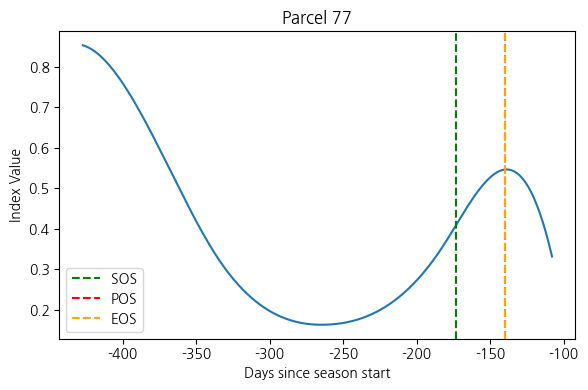

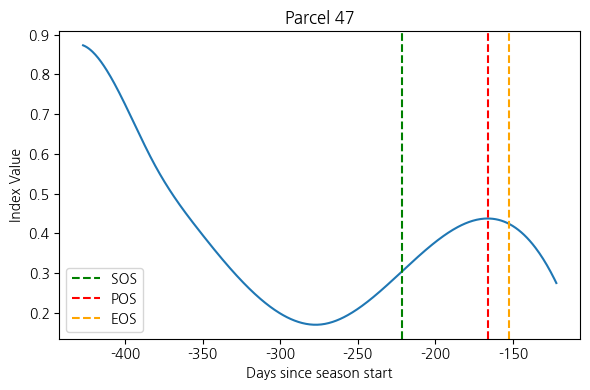

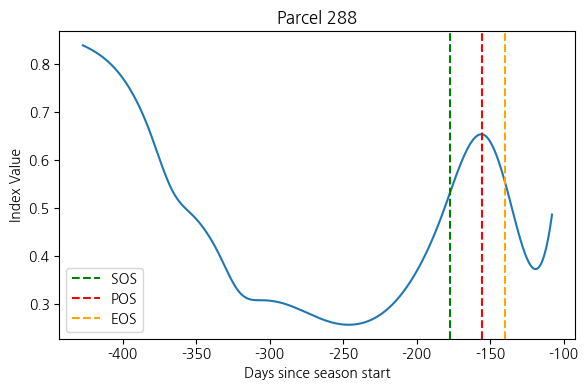

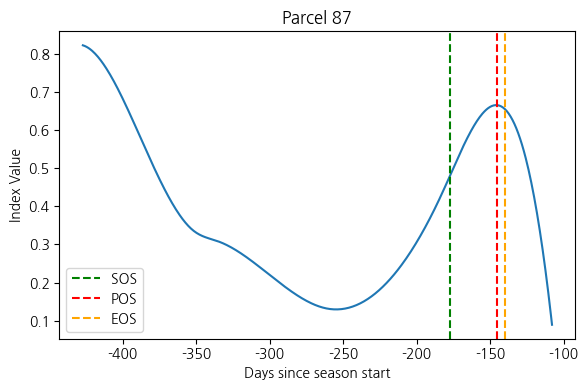

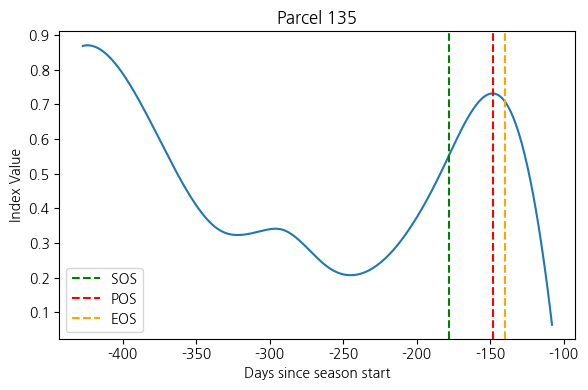

In [221]:
import random
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fix the root cause: add the missing 'day_num' column to df_parcel
if "day_num" not in df_parcel.columns:
    df_parcel["day_num"] = (df_parcel["date"] - pd.Timestamp(SEASON_START)).dt.days

sample_ids = random.sample(list(valid_parcels), 5)

for pid in sample_ids:
    # 2. Fit the curve on the fly if it's missing from the dictionary
    if pid not in all_curves_by_parcel:
        sub = df_parcel[df_parcel["parcel_id"] == pid].dropna(subset=["value"]).sort_values("date")
        day_num = sub["day_num"].values
        values = sub["value"].values

        spline_obj, dense_days, fitted_curve = fit_spline(day_num, values)
        points, derivative = extract_derivative_points_all(dense_days, fitted_curve)

        all_curves_by_parcel[pid] = (dense_days, fitted_curve, points, pd.Timestamp(SEASON_START))

    # 3. Plot
    dense_days, fitted_curve, points, base_date = all_curves_by_parcel[pid]

    plt.figure(figsize=(6, 4))
    plt.plot(dense_days, fitted_curve)
    plt.axvline(points["SOS_day"], linestyle="--", label="SOS", color="green")
    plt.axvline(points["POS_day"], linestyle="--", label="POS", color="red")
    plt.axvline(points["EOS_day"], linestyle="--", label="EOS", color="orange")
    plt.title(f"Parcel {pid}")
    plt.xlabel("Days since season start")
    plt.ylabel("Index Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [222]:
all_results = []
all_curves_by_parcel = {}
failed_parcels = []

for pid in valid_parcels:
    sub = df_parcel[df_parcel["parcel_id"] == pid].dropna(subset=["value"]).sort_values("date")
    if len(sub) < 4:
        failed_parcels.append((pid, "too few valid points"))
        continue
    try:
        day_num = sub["day_num"].values
        values = sub["value"].values
        base_date = BASE_DATE

        spline_obj, dense_days, fitted_curve = fit_spline(day_num, values)
        points, derivative = extract_derivative_points_all(dense_days, fitted_curve)
        features = extract_curve_shape_features(dense_days, fitted_curve, derivative, points)
        features["parcel_id"] = pid
        features["n_pixels_max"] = pixel_counts[pid]
        all_results.append(features)

        all_curves_by_parcel[pid] = (dense_days, fitted_curve, points, base_date)
    except Exception as e:
        failed_parcels.append((pid, str(e)))

print(f"Fitted {len(all_results)} / {len(valid_parcels)} parcels; {len(failed_parcels)} failed.\n")

# 1. Build the features table
features_df = pd.DataFrame(all_results)

# 2. Join to the actual parcel geometries
#    (onion_parcels already has parcel_id from Step 1 earlier)
onion_parcels_with_features = onion_parcels.merge(
    features_df, on="parcel_id", how="inner"
)

print(f"{len(onion_parcels_with_features)} / {len(onion_parcels)} parcels have features")

/tmp/ipykernel_65834/1219261114.py:145: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  spl = UnivariateSpline(x_train, y_train, s=s)


Fitted 300 / 300 parcels; 0 failed.

300 / 301 parcels have features


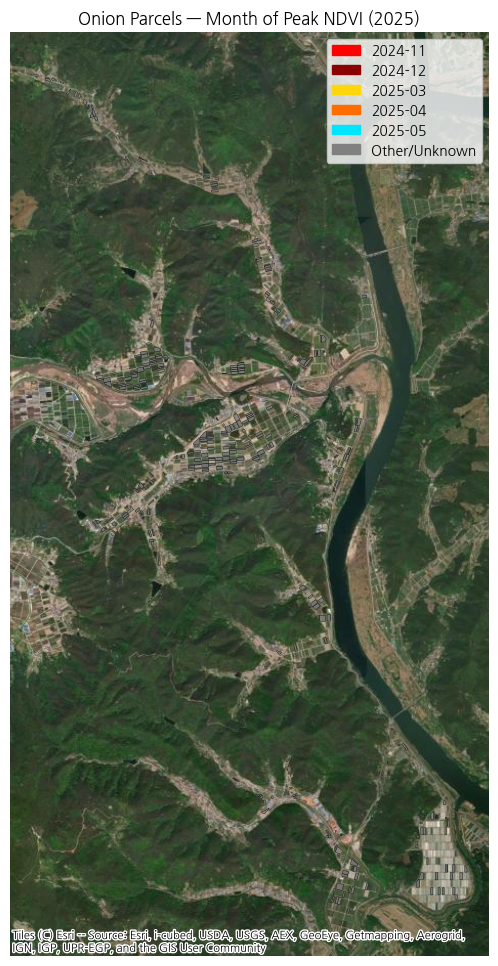

In [223]:
import contextily as ctx
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 12))

plot_gdf = onion_parcels_with_features.to_crs(epsg=3857)

# Calculate POS_date and POS_month for plotting
plot_gdf["POS_date"] = BASE_DATE + pd.to_timedelta(
    plot_gdf["Peak_Timing_day"], unit="D"
)
plot_gdf["POS_month"] = plot_gdf["POS_date"].dt.strftime("%Y-%m")

# bright = normal onion season, red = suspicious outliers
color_map = {
    f"{year-1}-11": "#ff0000",  # bright red
    f"{year-1}-12": "#8b0000",  # dark red
    f"{year}-03": "#ffd60a",  # bright yellow
    f"{year}-04": "#ff6d00",  # bright orange
    f"{year}-05": "#00e5ff",  # bright cyan
}

# Map colors and fill unexpected months with gray to avoid nan errors
plot_gdf["color"] = plot_gdf["POS_month"].map(color_map).fillna("gray")

plot_gdf.plot(
    color=plot_gdf["color"],
    ax=ax,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.3
)

# build legend manually since we're not using column= anymore
legend_handles = [mpatches.Patch(color=c, label=m) for m, c in color_map.items()]
if (plot_gdf["color"] == "gray").any():
    legend_handles.append(mpatches.Patch(color="gray", label="Other/Unknown"))

ax.legend(handles=legend_handles, loc="upper right")

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
ax.set_title(f"Onion Parcels — Month of Peak NDVI ({year})")
ax.set_axis_off()
plt.show()

In [224]:
ctx.providers.Esri.WorldImagery      # Esri provides high-quality satellite imagery without needing an API key
ctx.providers.CartoDB.Positron       # not satellite, but a clean street map if imagery is too messy

{'url': 'https://{s}.basemaps.cartocdn.com/{variant}/{z}/{x}/{y}{r}.png?key={apikey}',
 'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
 'attribution': '(C) OpenStreetMap contributors (C) CARTO',
 'subdomains': 'abcd',
 'max_zoom': 20,
 'variant': 'light_all',
 'apikey': '<insert your API key here>',
 'name': 'CartoDB.Positron'}

In [225]:
outliers = plot_gdf[plot_gdf["POS_month"].str.endswith(("-11", "-12"))]
outlier_ids = outliers["parcel_id"].tolist()

if len(outlier_ids) > 0:
    fig, ax = plt.subplots(figsize=(8, 8))
    if plot_gdf.crs is None:
        plot_gdf = plot_gdf.set_crs(raster_crs)

    outlier_gdf = plot_gdf[plot_gdf["parcel_id"].isin(outlier_ids)].to_crs(epsg=3857)
    outlier_gdf.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery, zoom=18)

    ax.set_title("Outlier Parcels (Nov/Dec Peak)")
    ax.set_axis_off()
    plt.show()
else:
    print("No outliers were found for Nov/Dec/Oct.")

No outliers were found for Nov/Dec/Oct.


In [226]:
onion_parcels_with_features = onion_parcels.merge(
    features_df, on="parcel_id", how="inner")

In [227]:
print(f"Total onion parcels loaded: {len(onion_parcels)}")
print(f"Parcels passing MIN_PIXELS: {len(valid_parcels)}")
print(f"Parcels with fitted features: {len(features_df)}")
print(f"Parcels shown on map: {len(onion_parcels_with_features)}")

Total onion parcels loaded: 301
Parcels passing MIN_PIXELS: 300
Parcels with fitted features: 300
Parcels shown on map: 300


In [228]:
dropped = onion_parcels[~onion_parcels["parcel_id"].isin(features_df["parcel_id"])]
print(f"{len(dropped)} parcels dropped")

# were they dropped for being too small, or for failing to fit?
dropped_reasons = dropped["parcel_id"].isin(pixel_counts[pixel_counts < MIN_PIXELS].index)
print(f"  - too few pixels: {dropped_reasons.sum()}")
print(f"  - fit failed for other reasons: {(~dropped_reasons).sum()}")

1 parcels dropped
  - too few pixels: 1
  - fit failed for other reasons: 0


In [229]:
gdf_all = gpd.read_file(PARCEL_PATH)
print(gdf_all["CROP_NM"].value_counts())

CROP_NM
양파    539
Name: count, dtype: int64


In [230]:
print(f"Total onion parcels in file: {len(gdf_all)}")
print(gdf_all["STDG_ADDR"].str.extract(r'(\S+시|\S+군)\s+(\S+면|\S+읍|\S+동)')[1].value_counts())

Total onion parcels in file: 539
1
청덕면    270
초계면    269
Name: count, dtype: int64


In [231]:
print(f"초계면 onion parcels: {len(onion_parcels)}")
print(f"초계면 onion parcel total area: {onion_parcels.geometry.area.sum():.0f} m²")

# rough bounding area of the visible farmland grid, for comparison
minx, miny, maxx, maxy = onion_parcels.total_bounds
print(f"Bounding box area: {(maxx-minx)*(maxy-miny):.0f} m²")

초계면 onion parcels: 301
초계면 onion parcel total area: 808090 m²
Bounding box area: 83272971 m²
